# Oil Services Provider

In [1]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Getting Data

In [2]:
df_oih = (pd.read_parquet(
    path = r"data/OilServicesTickersPX.parquet").
    pivot(index = "date", columns = "ticker", values = "Adj Close").
    pct_change().
    reset_index().
    melt(id_vars = "date").
    dropna())

In [3]:
commod_tickers = (pd.read_excel(
    io = "data/tickers.xlsx", sheet_name = "relationship").
    query("Ticker == 'OIH'").
    fut_ticker.
    drop_duplicates().
    to_list())

In [4]:
df_commod = (pd.read_parquet(
    path = r"data/commod_px.parquet").
    assign(security = lambda x: x.security.str.split("1").str[0]).
    query("security == @commod_tickers").
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "rtn"))

# Building Regression 

In [5]:
df_ols_setup = (df_oih.pivot(
    index = "date", columns = "ticker", values = "value").
    reset_index().
    melt(id_vars = ["date", "SPY", "OIH"], var_name = "endog_ticker", value_name = "endog_rtn").
    melt(id_vars = ["date", "endog_ticker", "endog_rtn"], var_name = "exog_ticker", value_name = "exog_rtn").
    dropna().
    assign(combined = lambda x: x.endog_ticker + " " + x.exog_ticker))

In [6]:
def _get_alpha(df: pd.DataFrame, window: int) -> pd.DataFrame:

    df_out = (RollingOLS(
        endog  = df.endog_rtn,
        exog   = sm.add_constant(df.exog_rtn),
        window = 30).
        fit().
        params.
        rename(columns = {
            "const"   : "eq_alpha",
            "exog_rtn": "eq_beta"}).
        merge(right = df, how = "inner", on = ["date"]))

    return df_out

window   = 30
df_alpha = (df_ols_setup.set_index(
    "date").
    groupby("combined").
    apply(_get_alpha, window, include_groups = False).
    reset_index())

In [7]:
df_alpha_combined = (df_alpha.assign(
    date = lambda x: pd.to_datetime(x.date)).
    merge(right = df_commod, how = "inner", on = ["date"]).
    dropna())

In [8]:
def _get_resid(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (sm.OLS(
        endog = df.rtn,
        exog  = sm.add_constant(df.eq_alpha)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = 10, labels = [i + 1 for i in range(10)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))

    return df_out

df_alpha_signal = (df_alpha_combined.set_index(
    "date").
    assign(group_var = lambda x: x.combined + " " + x.security).
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index().
    assign(signal_rtn = lambda x: -np.sign(x.lag_resid) * x.rtn))

In [9]:
df_wider = (df_alpha_signal.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

In [10]:
df_lag_longer = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.5, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "lagged"))

df_perf_longer = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.5, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "perfect"))

In [11]:
df_ols_combined = (pd.concat([
    df_lag_longer, df_perf_longer]).
    dropna())

In [12]:
df_plot = (df_ols_combined.assign(
    tmp  = lambda x: x.group_var.str.split(" "),
    name = lambda x: x.tmp.str[1] + " " + x.tmp.str[2] + " " + x.group).
    drop(columns = ["tmp"]).
    sort_values("group_var"))

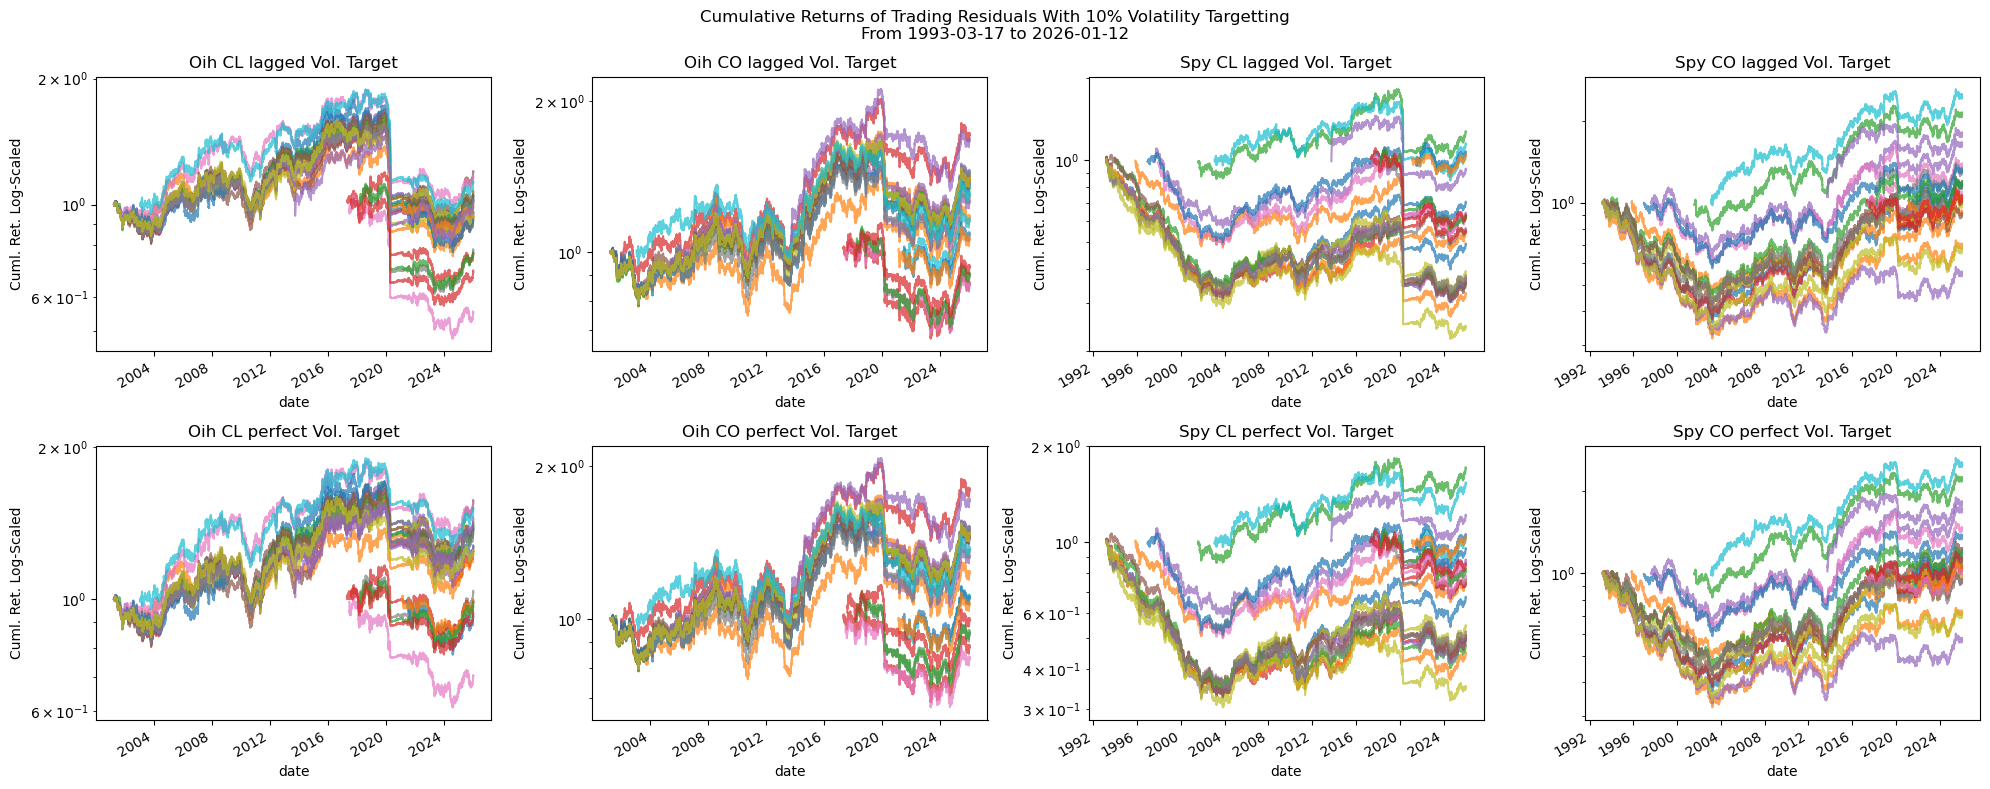

In [13]:
names     = df_plot.sort_values(["group"]).name.drop_duplicates().to_list()
fig, axes = plt.subplots(ncols = len(names) // 2, nrows = len(names) // 3, figsize = (20,8))

for name, ax in zip(names, axes.flatten()):

    (df_plot.query(
        "name == @name").
        pivot(index = "date", columns = "group_var", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            legend = False, 
            alpha  = 0.7,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = name.capitalize().replace("co","CO").replace("cl", "CL") + " Vol. Target"))

fig.suptitle("Cumulative Returns of Trading Residuals With 10% Volatility Targetting\nFrom {} to {}".format(
    df_plot.date.min().date(),
    df_plot.date.max().date()))
plt.tight_layout()

In [14]:
df_setup = (df_plot[
    ["name", "rtn", "date"]].
    groupby(["name", "date"]).
    agg("mean").
    reset_index().
    assign(
        strat  = lambda x: x.name.str.split(" ").str[0] + " " + x.name.str.split(" ").str[1],
        target = lambda x: x.name.str.split(" ").str[-1]))

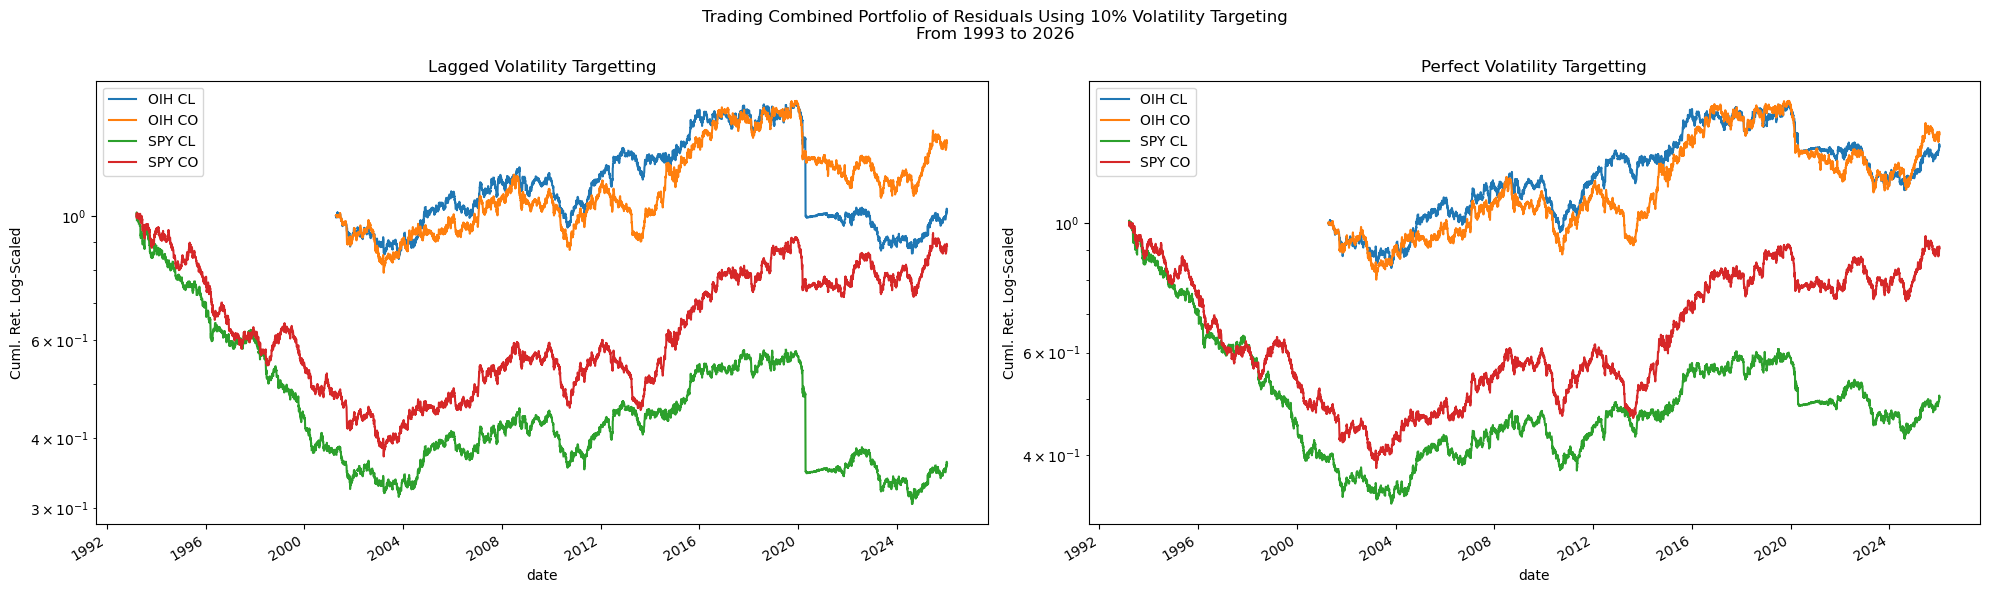

In [15]:
group_vars = df_setup.target.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_setup.query(
        "target == @group_var").
        rename(columns = {"strat": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targetting"))

fig.suptitle("Trading Combined Portfolio of Residuals Using 10% Volatility Targeting\nFrom {} to {}".format(
    df_setup.date.min().year,
    df_setup.date.max().year))

plt.tight_layout()

In [16]:
(df_setup[
    ["strat", "target", "rtn"]].
    groupby(["strat", "target"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(target = lambda x: x.target.str.capitalize()).
    rename(columns = {
        "strat": "",
        "target": "Vol. Target"}).
    pivot(index = "", columns = "Vol. Target", values = "rtn").
    apply(lambda x: np.round(x,3)))

Vol. Target,Lagged,Perfect
,,
OIH CL,0.069,0.207
OIH CO,0.174,0.198
SPY CL,-0.284,-0.221
SPY CO,0.012,0.016


# Trading Optimized Residuals

In [17]:
df_decile_sharpe = (df_alpha_signal[
    ["group_var", "decile", "rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"rtn": "sharpe"}).
    reset_index())

In [18]:
df_decile_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

In [19]:
df_decile_opt = (df_decile_tmp.drop(
    columns = ["decile"]).
    groupby(["group_var", "group"]).
    agg("prod").
    assign(signal_scaler = lambda x: np.where(x.sharpe > 0, 1, 0)).
    reset_index().
    drop(columns = ["sharpe"]).
    merge(right = df_decile_tmp, how = "outer", on = ["group", "group_var"]).
    merge(right = df_alpha_signal, how = "outer", on = ["group_var", "decile"]).
    assign(opt_rtn = lambda x: np.sign(x.sharpe * x.signal_scaler) * x.signal_rtn))

In [20]:
df_opt_wider = (df_decile_opt.pivot(
    index = "date", columns = "group_var", values = "opt_rtn"))

In [21]:
df_lag_longer = (df_opt_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.5, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "lagged"))

df_perf_longer = (df_opt_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.5, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "perfect"))

In [22]:
df_opt_combined = (pd.concat([
    df_lag_longer, df_perf_longer]).
    dropna())

In [23]:
df_prep = (df_opt_combined.assign(
    name = lambda x: x.group_var.str.split(" ").str[1] + " " + x.group_var.str.split(" ").str[2] + " " + x.group).
    sort_values("group"))

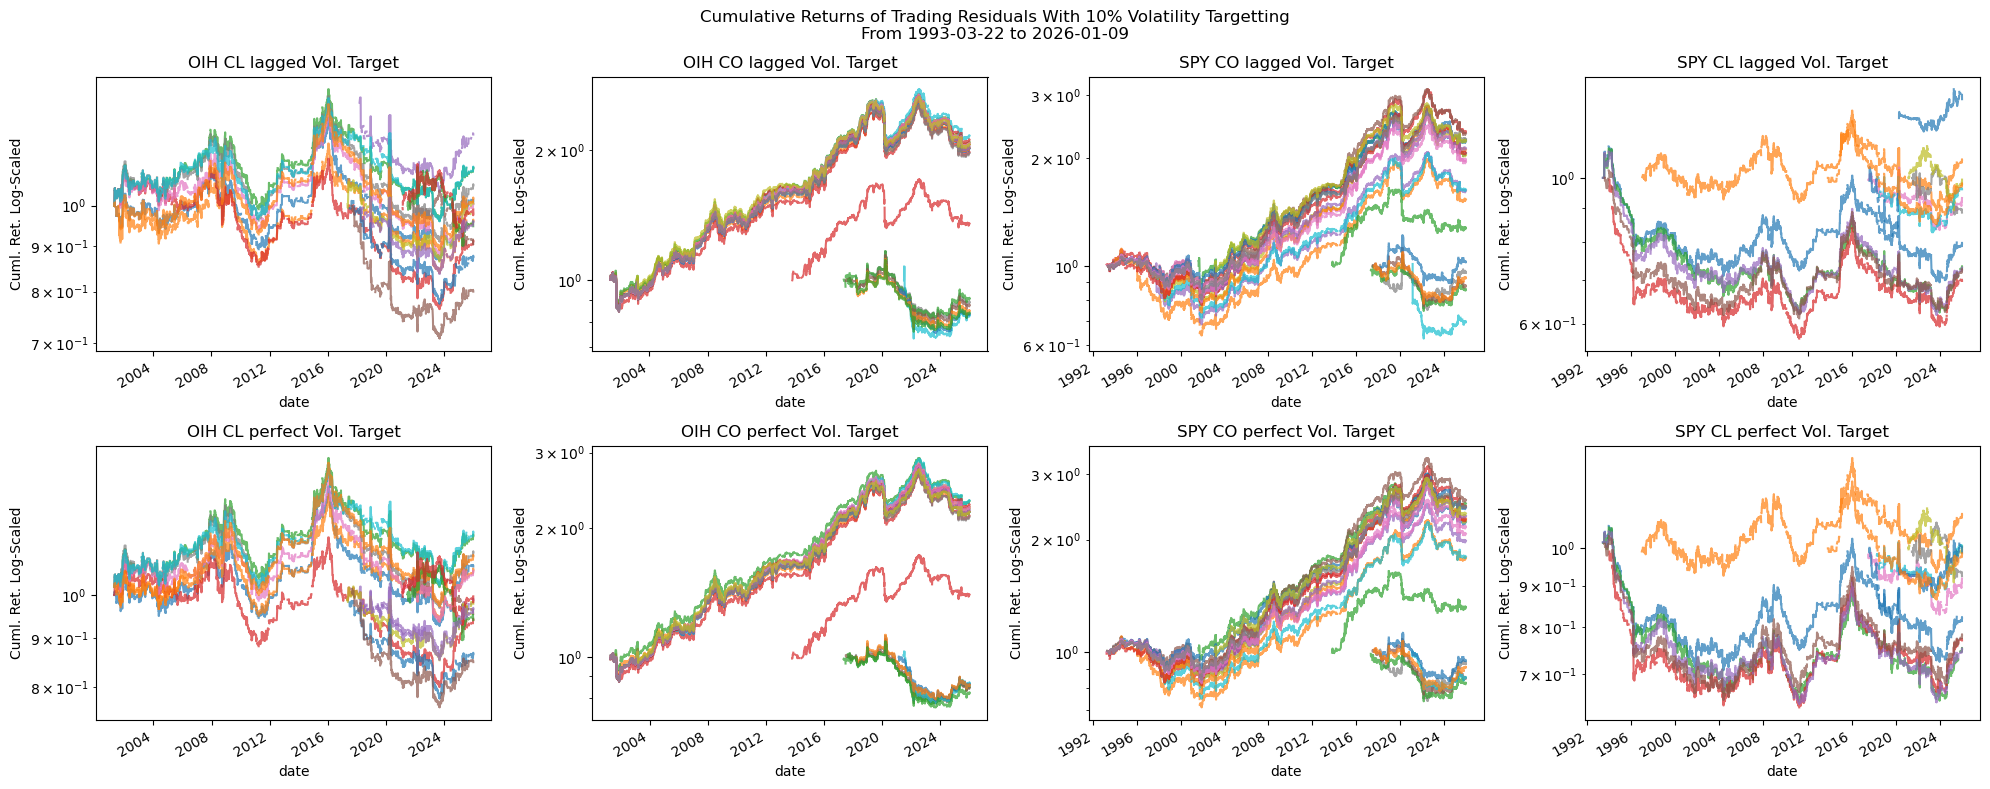

In [24]:
names     = df_prep.sort_values(["group"]).name.drop_duplicates().to_list()
fig, axes = plt.subplots(ncols = len(names) // 2, nrows = len(names) // 3, figsize = (20,8))

for name, ax in zip(names, axes.flatten()):

    (df_prep.query(
        "name == @name").
        pivot(index = "date", columns = "group_var", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            legend = False, 
            alpha  = 0.7,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = name + " Vol. Target"))

fig.suptitle("Cumulative Returns of Trading Residuals With 10% Volatility Targetting\nFrom {} to {}".format(
    df_prep.date.min().date(),
    df_prep.date.max().date()))
plt.tight_layout()

In [25]:
df_port = (df_prep.drop(
    columns = ["group_var", "group"]).
    groupby(["date", "name"]).
    agg("mean").
    reset_index().
    assign(
        group_var = lambda x: x.name.str.split(" ").str[0] + " " + x.name.str.split(" ").str[1],
        target    = lambda x: x.name.str.split(" ").str[-1]))

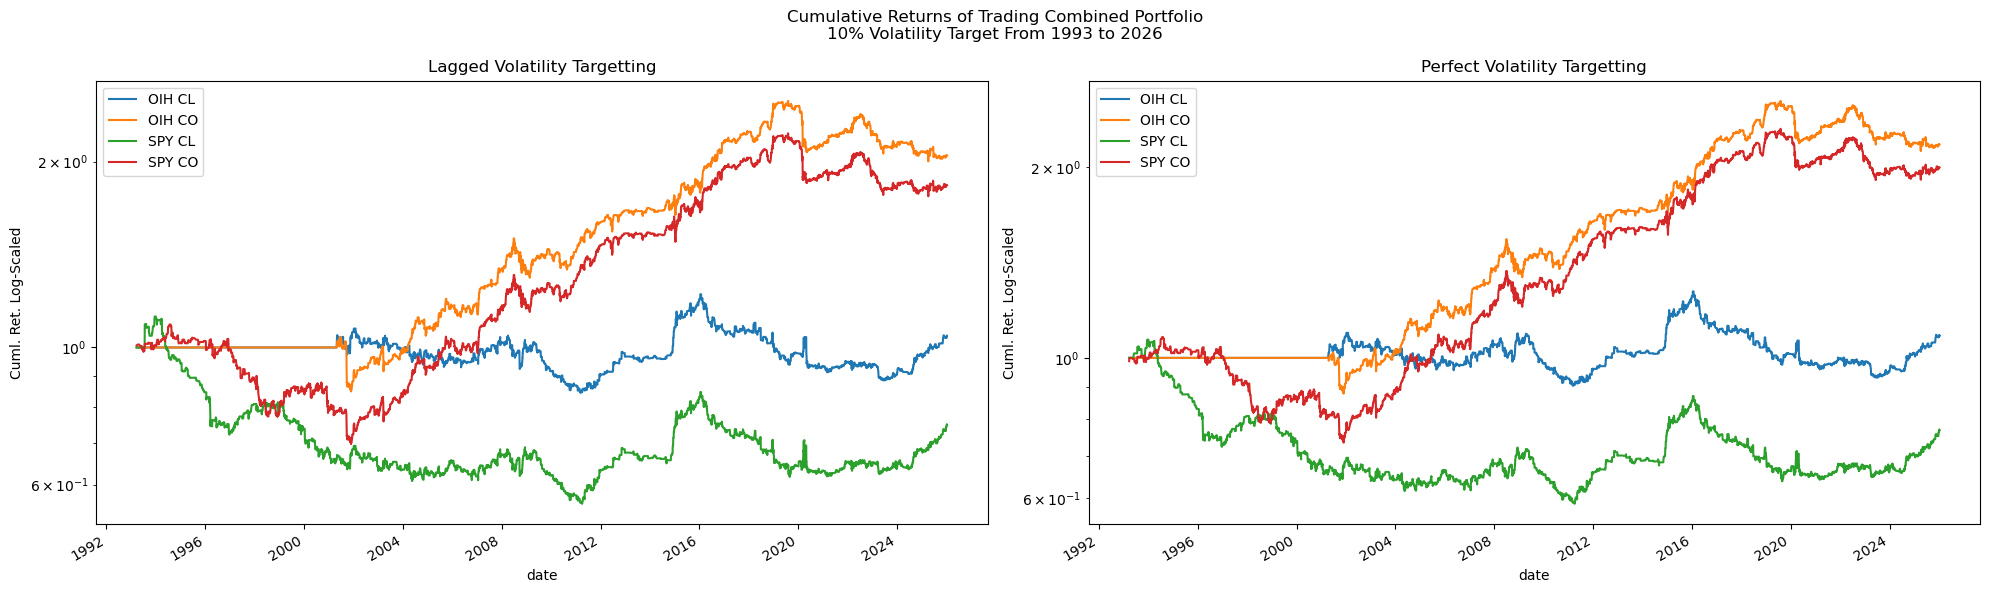

In [27]:
group_vars = df_port.target.drop_duplicates().sort_values()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    (df_port.query(
        "target == @group_var").
        rename(columns = {"group_var": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Returns of Trading Combined Portfolio\n10% Volatility Target From {} to {}".format(
    df_port.date.min().year,
    df_port.date.max().year))

plt.tight_layout()

In [28]:
(df_port.drop(
    columns = ["name"]).
    rename(columns = {"rtn": "raw_val"}).
    assign(adj_val = lambda x: np.where(x.raw_val != 0, x.raw_val, np.nan)).
    melt(id_vars = ["date", "group_var", "target"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["group_var", "target", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "variable" : "",
        "group_var": "Strat"}).
    replace({
        "adj_val": "Adj Sharpe",
        "raw_val": "Raw Sharpe"}).
    pivot(index = "Strat", columns = ["target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

target     lagged               perfect           
       Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
Strat                                             
OIH CL      0.125      0.095      0.183      0.140
OIH CO      0.910      0.740      1.077      0.876
SPY CL     -0.193     -0.149     -0.212     -0.164
SPY CO      0.557      0.455      0.675      0.551

In [31]:
(df_port[
    ["target", "group_var", "rtn"]].
    groupby(["target", "group_var"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)))

rtn
target  group_var          
lagged  OIH CL     0.095022
        OIH CO     0.740125
        SPY CL    -0.149354
        SPY CO     0.455402
perfect OIH CL     0.139549
        OIH CO     0.875743
        SPY CL    -0.164212
        SPY CO     0.551210